# NFXP — Original Dynamic Demand Model

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

## Model

The consumer chooses each period $t$: $y_{it} \in \{0, 1, \ldots, J\}$ — either no purchase ($y=0$) or brand $j \in \{1,\ldots,J\}$.

**State variable:** $x_{it} = (\ell_{it},\, d_{it},\, e_t)$ where
- $\ell_{it}$: last-purchased brand
- $d_{it}$: time since last purchase
- $e_t$: promotion status (exogenous Markov chain)

**Utility (equation 1):**
$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}(\ell_{it})\cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}$$

- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\gamma \cdot p_{it}(j)$: disutility from expenditure
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

**Transition rule:**
$$
(\ell_{i,t+1},\, d_{i,t+1}) = \begin{cases}
  (\ell_{it},\, d_{it}+1) & \text{if } y_{it}=0 \\
  (j,\, 1) & \text{if } y_{it}=j
\end{cases}
$$

**Estimator:** NFXP (Rust 1987) — Nelder-Mead outer loop, VFI inner loop.

## 1. Import

In [1]:
# Standard library and scientific computing imports
import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# 1. Simulation

## 2. Primitives and True Parameters

In [2]:
# ── Model dimensions ──────────────────────────────────────────────────────────
J     = 2       # number of brands
T     = 52      # periods per consumer
N     = 2_000   # consumers per panel
D_MAX = 20      # duration cap: d_idx ∈ {0,...,D_MAX}, paper-d ∈ {1,...,D_MAX+1}
DELTA = 0.95    # discount factor

# ── Price levels ──────────────────────────────────────────────────────────────
BASE_PRICES   = np.array([11.95, 24.95])   # regular unit prices
PROMO_DISC    = np.array([1.95,  15.67])   # promotion discount
PROMO_ENTRY   = 0.18                       # P(promotion starts)
PROMO_PERSIST = 0.0                        # P(promotion persists)

# ── True structural parameters (DGP) ─────────────────────────────────────────
#
#   u(0) = α(ℓ)  − β^dep[ℓ] · d
#   u(j) = α(j)  − γ · p(j) − β^sc(ℓ, j)
#
ALPHA_TRUE    = np.array([0.0,  0.50])           # α(1)=0 is the normalization
GAMMA_TRUE    = 0.05                             # marginal expenditure disutility
BETA_SC_TRUE  = np.array([[0.00, 0.25],          # β^sc[k,j]: switching cost k→j
                           [0.25, 0.00]])
BETA_DEP_TRUE = np.array([0.275, 0.275])         # β^dep[ℓ]: brand-specific depreciation rate

# ── Monte Carlo ───────────────────────────────────────────────────────────────
MC_REPS = 5
MC_SEED = 2024

# ── Choice indexing ───────────────────────────────────────────────────────────
# choice c = 0   → no purchase
# choice c = j   → buy brand j ∈ {1,...,J}
N_CHOICES = J + 1   # 3 choices: {0, 1, 2}

# ── Parameter vector ──────────────────────────────────────────────────────────
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc_12", "beta_sc_21",
               "beta_dep_1", "beta_dep_2"]

THETA_TRUE = np.array([
    ALPHA_TRUE[1],
    GAMMA_TRUE,
    BETA_SC_TRUE[0, 1],
    BETA_SC_TRUE[1, 0],
    BETA_DEP_TRUE[0],
    BETA_DEP_TRUE[1],
])

print("True parameters:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  D_MAX={D_MAX}")

True parameters:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc_12     = 0.25
  beta_sc_21     = 0.25
  beta_dep_1     = 0.275
  beta_dep_2     = 0.275

N_CHOICES=3  |  BASE_PRICES=[11.95 24.95]  |  D_MAX=20


## 3. Price Process — Hi-Lo (Assumption 2.1)

Promotion status $e_t \in \{0,1\}^J$ is a binary vector. With $J=2$ there are $2^2=4$ possible states. Brand promotions follow independent two-state Markov chains, and the joint transition probability is the product of the marginal probabilities.

In [3]:
# Enumerate all 2^J joint promotion states as binary vectors
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)


def make_promo_transition() -> np.ndarray:
    # Build joint transition matrix as product of independent brand Markov chains
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


PROMO_TRANS = make_promo_transition()
PRICE_BY_PROMO = BASE_PRICES - PROMO_DISC * promo_states

print("Unit prices by promotion state:")
for s, e in enumerate(promo_states):
    p = PRICE_BY_PROMO[s]
    print(f"  State {s}: e={tuple(e)}  p={p}")

Unit prices by promotion state:
  State 0: e=(0, 0)  p=[11.95 24.95]
  State 1: e=(1, 0)  p=[10.   24.95]
  State 2: e=(0, 1)  p=[11.95  9.28]
  State 3: e=(1, 1)  p=[10.    9.28]


## 4. Utility Function (equation 1)

$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}[\ell_{it}] \cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}$$

- $\gamma \cdot p_{it}(j)$: disutility from expenditure (linear in price)
- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

In [4]:
def flow_util(choice, last_brand, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """
    Deterministic period utility.

    choice    : 0 = no purchase; j ∈ {1,...,J} → buy brand j
    last_brand: ℓ ∈ {1,...,J}
    duration  : paper-d = d_idx + 1  ∈ {1,...,D_MAX+1}
    beta_dep  : (J,) array — brand-specific depreciation rate
    """
    l      = last_brand - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    if choice == 0:
        # No purchase: inventory depreciates at brand-specific rate
        return alpha[l] - beta_dep[l] * duration

    j = choice - 1   # brand index (0-indexed)
    return alpha[j] - gamma * prices[j] - beta_sc[l, j]

## 5. Inner Loop: Value Function Iteration (VFI)

**State space:** $(\ell, d, e)$, $J \times (D_{\max}+1) \times N_e = 2 \times 4 \times 4 = 32$ states.

$V$ has shape `(J, D_MAX+1, N_PROMO)`.

Transition rules in VFI:
- No purchase: $(\ell, d_{\rm idx}) \to (\ell, \min(d_{\rm idx}+1, D_{\rm MAX}))$
- Purchase $j$: $(\ell, d_{\rm idx}) \to (j, 0)$ (paper-$d=1$)

In [5]:
def solve_vfi(alpha, gamma, beta_sc, beta_dep,
              tol: float = 1e-10, max_iter: int = 2_000) -> np.ndarray:
    """
    VFI for the original model (brand-specific β^dep).

    V shape: (J, D_MAX+1, N_PROMO).
    d_idx ∈ {0,...,D_MAX} corresponds to paper-d = d_idx + 1.
    """
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        # Expected continuation value (integrate over promotion process)
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)

        # No purchase: state → (ℓ, min(d_idx+1, D_MAX), e')
        Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

        # Purchase brand j: state → (j, d_idx=0, e')  [paper d=1]
        for j_idx in range(J):
            Q[..., j_idx + 1] = (
                alpha[j_idx]
                - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
                - beta_sc[:, j_idx][:, None, None]
                + DELTA * EV[j_idx, 0, :][None, None, :]
            )

        # Log-sum-exp for the Emax (Gumbel extreme value assumption)
        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))

        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V

## 6. Conditional Choice Probabilities (CCPs)

$$P(j \mid s;\theta) = \frac{\exp(Q_j)}{\sum_{k}\exp(Q_k)}, \quad Q_j = u(j, s) + \delta\cdot EV(\text{next state})$$

`P` shape: `(J, D_MAX+1, N_PROMO, N_CHOICES)`.

In [6]:
def compute_ccps(V, alpha, gamma, beta_sc, beta_dep) -> np.ndarray:
    """
    Compute CCPs from solved value function V.
    P shape: (J, D_MAX+1, N_PROMO, N_CHOICES).
    """
    duration_idx = np.arange(D_MAX + 1)
    duration = duration_idx + 1.0
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Expected continuation value integrated over next promotion state
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

    for j_idx in range(J):
        Q[..., j_idx + 1] = (
            alpha[j_idx]
            - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
            - beta_sc[:, j_idx][:, None, None]
            + DELTA * EV[j_idx, 0, :][None, None, :]
        )

    # Softmax to get choice probabilities
    weights = np.exp(Q - Q.max(axis=3, keepdims=True))
    return weights / weights.sum(axis=3, keepdims=True)

## 7. Data Simulation

`simulate_panel` simulates a consumer panel from the model's CCPs and returns:
- `Y` ∈ {0,...,J}: brand choice (0 = no purchase)
- `L`: last-purchased brand (state variable)
- `D`: duration since last purchase, d_idx ∈ {0,...,D_MAX}
- `E_IDX`: promotion status

In [7]:
def _sample_rows(rng, row_probs: np.ndarray) -> np.ndarray:
    """Vectorized categorical draw: one observation per row of row_probs."""
    u = rng.random(len(row_probs))
    cumsum = np.cumsum(row_probs, axis=1)
    return (u[:, None] > cumsum).sum(axis=1)


def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N, n_periods: int = T,
                   seed=None) -> dict:
    """
    Simulate consumer panel from CCPs.
    P_true shape: (J, D_MAX+1, N_PROMO, N_CHOICES).

    Returns dict: Y, L, D, E_IDX — all (n_consumers, n_periods).
    """
    rng = np.random.default_rng(seed)

    # Pre-allocate arrays for the full panel
    Y     = np.zeros((n_consumers, n_periods), dtype=int)
    L     = np.zeros((n_consumers, n_periods), dtype=int)
    D     = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    # Random initial states
    ell   = rng.integers(1, J + 1,     size=n_consumers)
    dur   = rng.integers(0, D_MAX + 1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO,   size=n_consumers)

    for t in range(n_periods):
        # Record current state
        L[:, t]     = ell
        D[:, t]     = dur
        E_IDX[:, t] = e_idx

        # CCP lookup: state (ℓ-1, min(d,D_MAX), e)
        probs = P_true[ell - 1, np.minimum(dur, D_MAX), e_idx, :]
        y = _sample_rows(rng, probs)
        Y[:, t] = y

        # Update state variables (transition rule)
        bought = y > 0
        ell    = np.where(bought, y, ell)                      # new brand if purchased
        dur    = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        e_idx  = _sample_rows(rng, PROMO_TRANS[e_idx])

    return {"Y": Y, "L": L, "D": D, "E_IDX": E_IDX}

## 8. Log-Likelihood and NFXP

**Log-likelihood:**
$$\ell(\theta) = \sum_{i,t} \log P(y_{it} \mid \ell_{it}, d_{it}, e_{it}; \theta)$$

**NFXP (Rust 1987):** outer Nelder-Mead minimizes $-\ell(\theta)$; inner VFI solves the Bellman equation at each candidate $\theta$.

**Parameter vector:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{sc}_{12},\; \beta^{sc}_{21},\; \beta^{dep}_1,\; \beta^{dep}_2]$$

In [8]:
def log_likelihood(data: dict, P: np.ndarray) -> float:
    """Summed log-likelihood over all (i,t) observations."""
    Y, L, D, E = data["Y"], data["L"], data["D"], data["E_IDX"]
    probs = P[L - 1, D, E, Y]
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


def state_choice_counts(data: dict) -> np.ndarray:
    """Aggregate simulated panel observations by state and realized choice."""
    counts = np.zeros((J, D_MAX + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (
            data["L"].ravel() - 1,
            data["D"].ravel(),
            data["E_IDX"].ravel(),
            data["Y"].ravel(),
        ),
        1.0,
    )
    return counts


def log_likelihood_counts(counts: np.ndarray, P: np.ndarray) -> float:
    """Summed log-likelihood using state-choice counts."""
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


def unpack(theta: np.ndarray):
    """Unpack theta = [alpha_2, gamma, beta_sc_12, beta_sc_21, beta_dep_1, beta_dep_2]."""
    alpha    = np.array([0.0, theta[0]])
    gamma    = float(theta[1])
    beta_sc  = np.array([[0.0, theta[2]], [theta[3], 0.0]])
    beta_dep = np.array([theta[4], theta[5]])   # (J,) brand-specific rates
    return alpha, gamma, beta_sc, beta_dep


def nfxp_objective(theta: np.ndarray, data_or_counts) -> float:
    # Solve VFI, compute CCPs, and return negative log-likelihood.
    # Passing pre-aggregated counts is algebraically equivalent and faster.
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood_counts(counts, P)


def estimate_nfxp(data: dict, theta0: np.ndarray = None, verbose: bool = False):
    """Estimate the model with NFXP (Nelder-Mead)."""
    if theta0 is None:
        theta0 = np.array([0.1, 0.03, 0.3, 0.3, 0.2, 0.2])
    counts = state_choice_counts(data)
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(counts,),
        method="BFGS",
        options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )

## 9. Pilot — Single Panel

Verify that VFI converges, the simulation looks reasonable, and that NFXP recovers the true parameters from a single panel.

In [9]:
print("Step 1: Solving DP at true parameters...")
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI converged.")

print(f"\nStep 2: Simulating panel (N={N}, T={T})...")
data_pilot = simulate_panel(P_true, seed=42)
Y = data_pilot["Y"]
print(f"  No purchase: {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:     {(Y == j).mean():.1%}")

print("\nStep 3: Estimating with NFXP...")
# Perturb true parameters slightly as starting point
theta0_pilot = THETA_TRUE + np.array([0.05, 0.005, 0.05, 0.05, 0.02, 0.02])
t0 = time.perf_counter()
res_pilot = estimate_nfxp(data_pilot, theta0=theta0_pilot)
t1 = time.perf_counter() - t0
print(f"  Time: {t1:.1f}s  |  Converged: {res_pilot.success}  |  Iterations: {res_pilot.nit}")

print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "True":      THETA_TRUE,
    "NFXP":      res_pilot.x,
    "Bias":      res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Step 1: Solving DP at true parameters...
  VFI converged.

Step 2: Simulating panel (N=2000, T=52)...
  No purchase: 42.1%
  Brand 1:     23.9%
  Brand 2:     34.0%

Step 3: Estimating with NFXP...


/var/folders/ln/8cqzywtn28ngc9_bdjglb_y80000gn/T/ipykernel_90195/2768786354.py:53: OptimizeWarning: Unknown solver options: xatol, fatol, adaptive
  return minimize(


  Time: 3.8s  |  Converged: False  |  Iterations: 16

───────────────────────────────────────────────────────
 Parameter    True    NFXP    Bias
   alpha_2 +0.5000 +0.5030 +0.0030
     gamma +0.0500 +0.0509 +0.0009
beta_sc_12 +0.2500 +0.2486 -0.0014
beta_sc_21 +0.2500 +0.2467 -0.0033
beta_dep_1 +0.2750 +0.2756 +0.0006
beta_dep_2 +0.2750 +0.2828 +0.0078


## 10. Monte Carlo

For each replication:
1. Simulate a new panel from the DGP
2. Estimate the model with NFXP
3. Record estimates, bias, and RMSE

**Expected result:** low RMSE and bias close to zero for all 6 parameters.

In [10]:
def run_monte_carlo(n_reps: int = MC_REPS, seed: int = MC_SEED):
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Solve DP once at true parameters; all replications use the same DGP CCPs
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}")
    print(f"DGP: β^dep={BETA_DEP_TRUE}\n")

    rows = []
    for rep in range(1, n_reps + 1):
        # Simulate a new panel for this replication
        data = simulate_panel(P_t, n_consumers=N, n_periods=T,
                              seed=int(rep_seeds[rep - 1]))

        # Random perturbation around true parameters as starting point
        rng_s  = np.random.default_rng(int(rep_seeds[rep - 1]) + 999)
        pert   = rng_s.normal(0, 0.05, size=6)
        theta0 = THETA_TRUE + pert

        t0 = time.perf_counter()
        r  = estimate_nfxp(data, theta0=theta0)
        t1 = time.perf_counter() - t0

        print(f"  Rep {rep:>3}/{n_reps}  conv={r.success}  ({t1:>4.0f}s)")

        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep":       rep,
                "param":     name,
                "true":      THETA_TRUE[k],
                "estimate":  r.x[k],
                "bias":      r.x[k] - THETA_TRUE[k],
                "sq_error":  (r.x[k] - THETA_TRUE[k]) ** 2,
                "converged": int(r.success),
            })

    # Aggregate bias, relative bias, RMSE, and confidence intervals across replications
    df = pd.DataFrame(rows)
    summary_rows = []
    for i, name in enumerate(PARAM_NAMES):
        g = df[df["param"] == name]
        estimates = g["estimate"].dropna()
        n_rep = int(estimates.size)
        mean_est = estimates.mean()
        bias = mean_est - THETA_TRUE[i]
        std = estimates.std(ddof=1)
        se_mean = std / np.sqrt(n_rep) if n_rep > 0 else np.nan
        rmse = np.sqrt(g["sq_error"].mean())
        true_value = THETA_TRUE[i]
        relative_bias_pct = 100 * bias / true_value if not np.isclose(true_value, 0.0) else np.nan

        if n_rep > 1 and np.isfinite(se_mean) and se_mean > 0:
            z_crit = 1.96
            ci95_lo = mean_est - z_crit * se_mean
            ci95_hi = mean_est + z_crit * se_mean
        else:
            ci95_lo = np.nan
            ci95_hi = np.nan

        summary_rows.append({
            "param":     name,
            "true":      THETA_TRUE[i],
            "n_rep":     n_rep,
            "mean_est":  mean_est,
            "bias":      bias,
            "rel_bias_pct": relative_bias_pct,
            "std":       std,
            "se_mean":   se_mean,
            "ci95_lo":   ci95_lo,
            "ci95_hi":   ci95_hi,
            "rmse":      rmse,
            "conv_rate": g["converged"].mean(),
        })

    summary = pd.DataFrame(summary_rows)

    return df, summary

In [11]:
# Run Monte Carlo and collect results and summary statistics
results, summary = run_monte_carlo()

MC  |  J=2, T=52, N=2000, D_MAX=20, reps=5
DGP: β^dep=[0.275 0.275]



/var/folders/ln/8cqzywtn28ngc9_bdjglb_y80000gn/T/ipykernel_90195/2768786354.py:53: OptimizeWarning: Unknown solver options: xatol, fatol, adaptive
  return minimize(


  Rep   1/5  conv=False  (   5s)


/var/folders/ln/8cqzywtn28ngc9_bdjglb_y80000gn/T/ipykernel_90195/2768786354.py:53: OptimizeWarning: Unknown solver options: xatol, fatol, adaptive
  return minimize(


  Rep   2/5  conv=False  (   4s)


...

  Rep   3/5  conv=False  (   3s)


/var/folders/ln/8cqzywtn28ngc9_bdjglb_y80000gn/T/ipykernel_90195/2768786354.py:53: OptimizeWarning: Unknown solver options: xatol, fatol, adaptive
  return minimize(


  Rep   4/5  conv=False  (   4s)


/var/folders/ln/8cqzywtn28ngc9_bdjglb_y80000gn/T/ipykernel_90195/2768786354.py:53: OptimizeWarning: Unknown solver options: xatol, fatol, adaptive
  return minimize(


  Rep   5/5  conv=False  (   3s)


## 11. Results

In [12]:
print("=" * 65)
print("NFXP Monte Carlo — original model (brand-specific β^dep)")
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 65)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

NFXP Monte Carlo — original model (brand-specific β^dep)
J=2, T=52, N=2000, D_MAX=20, reps=5
     param   true  n_rep  mean_est    bias  rel_bias_pct    std  se_mean  ci95_lo  ci95_hi   rmse  conv_rate
   alpha_2 0.5000      5    0.5025  0.0025        0.5026 0.0077   0.0034   0.4958   0.5093 0.0073     0.0000
     gamma 0.0500      5    0.0502  0.0002        0.4198 0.0005   0.0002   0.0498   0.0506 0.0005     0.0000
beta_sc_12 0.2500      5    0.2562  0.0062        2.4879 0.0489   0.0219   0.2133   0.2991 0.0442     0.0000
beta_sc_21 0.2500      5    0.2387 -0.0113       -4.5394 0.0374   0.0167   0.2059   0.2714 0.0353     0.0000
beta_dep_1 0.2750      5    0.2782  0.0032        1.1772 0.0092   0.0041   0.2702   0.2863 0.0088     0.0000
beta_dep_2 0.2750      5    0.2787  0.0037        1.3434 0.0046   0.0021   0.2746   0.2828 0.0056     0.0000


## 12. Visualization

Boxplots for all 6 parameters over Monte Carlo replications compared to the true values.

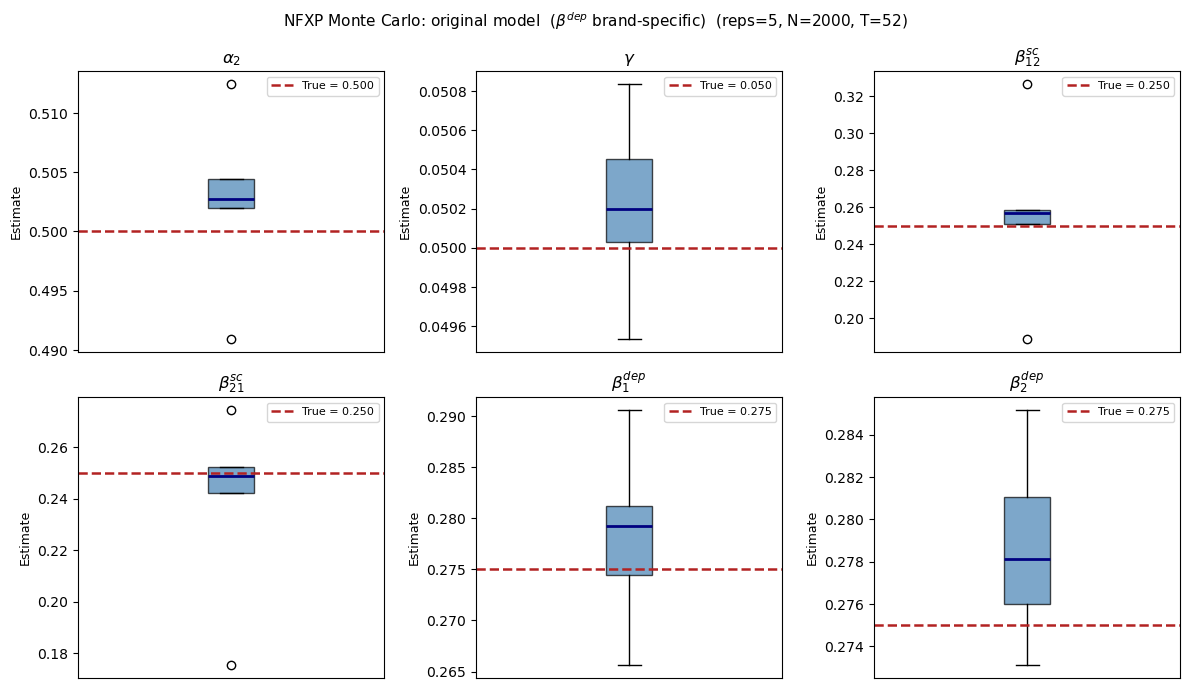

In [13]:
# LaTeX labels for each parameter (used in plots)
latex_lbl = {
    "alpha_2":    r"$\alpha_2$",
    "gamma":      r"$\gamma$",
    "beta_sc_12": r"$\beta^{sc}_{12}$",
    "beta_sc_21": r"$\beta^{sc}_{21}$",
    "beta_dep_1": r"$\beta^{dep}_1$",
    "beta_dep_2": r"$\beta^{dep}_2$",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    est    = results[results["param"] == name]["estimate"].to_numpy()
    true_v = THETA_TRUE[i]
    # Box shows distribution of MC estimates; dashed line marks true value
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"True = {true_v:.3f}")
    ax.set_title(latex_lbl.get(name, name), fontsize=12)
    ax.set_ylabel("Estimate", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.NullLocator())

fig.suptitle(
    r"NFXP Monte Carlo: original model  ($\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots_original.pdf", bbox_inches="tight")
plt.show()

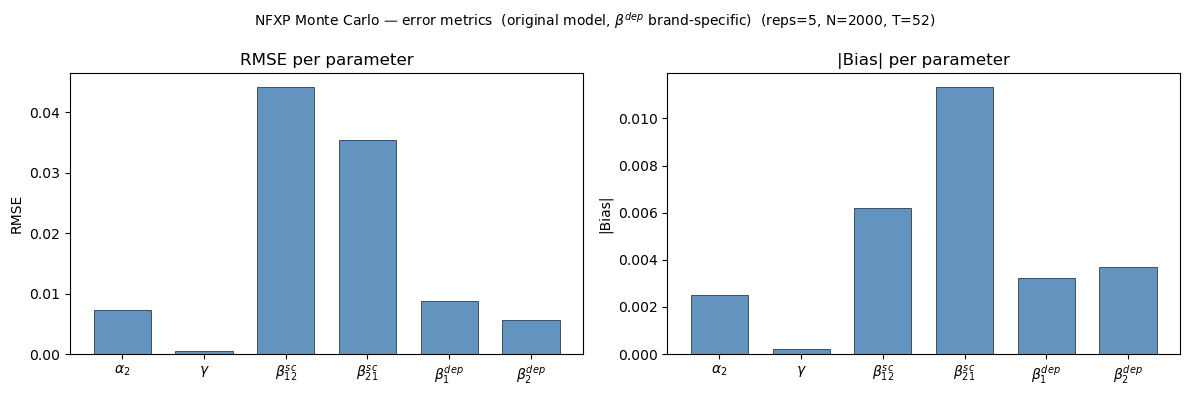

In [14]:
# Bias and RMSE bar chart — summarizes estimation accuracy across parameters
labels   = [latex_lbl.get(n, n) for n in PARAM_NAMES]
bias_abs = [abs(summary.loc[summary["param"] == n, "bias"].values[0]) for n in PARAM_NAMES]
rmse_v   = [summary.loc[summary["param"] == n, "rmse"].values[0]      for n in PARAM_NAMES]

x = np.arange(len(PARAM_NAMES))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, vals, ylabel, title in [
    (axes[0], rmse_v,   "RMSE",   "RMSE per parameter"),
    (axes[1], bias_abs, "|Bias|", "|Bias| per parameter"),
]:
    ax.bar(x, vals, 2 * w, color="steelblue", alpha=0.85, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="black", lw=0.5)

fig.suptitle(
    r"NFXP Monte Carlo — error metrics  (original model, $\beta^{dep}$ brand-specific)"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=10,
)
plt.tight_layout()
plt.savefig("nfxp_mc_bias_rmse_original.pdf", bbox_inches="tight")
plt.show()

# 2. Emipirical Application

In [1]:
import pandas as pd
import numpy as np

# ── Datapaths ────────────────────────────────────────────────────────────────
SCANNER_DATA     = "/Users/solveigroendalliniger/Desktop/netto_df.csv"
PRICE_PROMO_DATA = "/Users/solveigroendalliniger/Desktop/Price_Promo.xlsx"
# ────────────────────────────────────────────────────────────────────────────


# ── Brands ──────────────────────────────────────────────────────────────────
EMPIRICAL_BRANDS = [1, 2]

EMPIRICAL_PRICE_COLUMNS = {
    1: "Brand_1_price",
    2: "Brand_2_price",
}


# ── Load scanner panel ──────────────────────────────────────────────────────
netto_df = pd.read_csv(SCANNER_DATA)

# Fjern uge 53
netto_df = netto_df[netto_df["week_num"] != 53].copy()

# Datatyper
netto_df["Brand"] = netto_df["Brand"].astype(str)

netto_df["Price"] = (
    pd.to_numeric(netto_df["Price"], errors="coerce")
    .round(1)
)

netto_df["Customer_ID"] = (
    pd.to_numeric(netto_df["Customer_ID"], errors="coerce")
    .astype("Int64")
)

netto_df["week_num"] = (
    pd.to_numeric(netto_df["week_num"], errors="coerce")
    .astype("Int64")
)

netto_df["brand_id"] = (
    pd.to_numeric(netto_df["Brand"], errors="coerce")
    .fillna(0)
    .astype(int)
)


# ── Load price/promo Excel ──────────────────────────────────────────────────
price_promo_workbook = pd.ExcelFile(PRICE_PROMO_DATA)

print("Sheets in Price_Promo.xlsx:")
print(price_promo_workbook.sheet_names)

# Brug tredje sheet
price_promo_sheet_name = price_promo_workbook.sheet_names[2]
print(f"\nUsing sheet: {price_promo_sheet_name}")

price_promo_df = pd.read_excel(
    price_promo_workbook,
    sheet_name=price_promo_sheet_name
)


# ── Required columns ────────────────────────────────────────────────────────
price_promo_required_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Promo_Brand_1",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Promo_Brand_2",
]

missing_columns = [
    col for col in price_promo_required_columns
    if col not in price_promo_df.columns
]

if missing_columns:
    raise ValueError(
        f"Disse kolonner mangler i price_promo_df: {missing_columns}\n"
        f"Kolonner i arket er: {price_promo_df.columns.tolist()}"
    )

price_promo_df = price_promo_df[price_promo_required_columns].copy()


# ── Clean price/promo data ──────────────────────────────────────────────────
for column in price_promo_required_columns:
    price_promo_df[column] = pd.to_numeric(
        price_promo_df[column],
        errors="coerce"
    )

price_promo_df = price_promo_df.dropna(subset=["WeekNum"]).copy()
price_promo_df["WeekNum"] = price_promo_df["WeekNum"].astype(int)

# Tjek at der kun er én række per uge
if price_promo_df["WeekNum"].duplicated().any():
    duplicated_weeks = (
        price_promo_df.loc[
            price_promo_df["WeekNum"].duplicated(),
            "WeekNum"
        ]
        .unique()
    )

    raise ValueError(
        f"Der er dubletter i WeekNum i price_promo_df: {duplicated_weeks}"
    )


# ── Construct binary offered prices ─────────────────────────────────────────
# Pris = RRP hvis ingen promotion
# Pris = gennemsnitlig kampagnepris hvis promotion

EMPIRICAL_MEAN_DISCOUNT_PRICE = {}

for brand in EMPIRICAL_BRANDS:

    promo_column = f"Promo_Brand_{brand}"
    discount_column = f"Discount_Brand_{brand}"
    rrp_column = f"RRP_Brand_{brand}"

    price_column = f"Brand_{brand}_price"
    mean_discount_column = f"Mean_Discount_Brand_{brand}"

    price_promo_df[promo_column] = (
        price_promo_df[promo_column]
        .fillna(0)
        .astype(int)
    )

    promo_discount_mask = (
        (price_promo_df[promo_column] == 1) &
        (price_promo_df[discount_column].notna())
    )

    mean_discount_price = (
        price_promo_df.loc[promo_discount_mask, discount_column]
        .mean()
    )

    # Fallback hvis der ikke findes promotion-observationer
    if not np.isfinite(mean_discount_price):
        mean_discount_price = price_promo_df[discount_column].mean()

    # Fallback hvis discount-kolonnen er tom
    if not np.isfinite(mean_discount_price):
        mean_discount_price = price_promo_df[rrp_column].median()

    EMPIRICAL_MEAN_DISCOUNT_PRICE[brand] = mean_discount_price

    price_promo_df[mean_discount_column] = mean_discount_price

    price_promo_df[price_column] = np.where(
        price_promo_df[promo_column] == 1,
        mean_discount_price,
        price_promo_df[rrp_column]
    )


# ── Tjek at pris-kolonnerne faktisk findes ──────────────────────────────────
required_constructed_columns = [
    "Mean_Discount_Brand_1",
    "Mean_Discount_Brand_2",
    "Brand_1_price",
    "Brand_2_price",
]

missing_constructed_columns = [
    col for col in required_constructed_columns
    if col not in price_promo_df.columns
]

if missing_constructed_columns:
    raise ValueError(
        f"Disse pris-kolonner blev ikke lavet: {missing_constructed_columns}"
    )


# ── Print price support ─────────────────────────────────────────────────────
empirical_binary_price_summary = pd.DataFrame(
    [
        {
            "Brand": brand,
            "RRP median": price_promo_df[f"RRP_Brand_{brand}"].median(),
            "Mean sale price": EMPIRICAL_MEAN_DISCOUNT_PRICE[brand],
            "Promo weeks": int(price_promo_df[f"Promo_Brand_{brand}"].sum()),
        }
        for brand in EMPIRICAL_BRANDS
    ]
)

print("\nBinary empirical price support:")
print(
    empirical_binary_price_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


# ── Merge weekly price/promo data onto scanner panel ────────────────────────
price_promo_merge_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

netto_df = netto_df.merge(
    price_promo_df[price_promo_merge_columns],
    left_on="week_num",
    right_on="WeekNum",
    how="left",
    validate="many_to_one"
)


# ── Keep only rows with both alternative prices available ───────────────────
netto_df = netto_df.loc[
    netto_df["Brand_1_price"].notna() &
    netto_df["Brand_2_price"].notna()
].copy()


# ── Final check ─────────────────────────────────────────────────────────────
print(
    f"\nPanel: {netto_df['Customer_ID'].nunique():,} husstande, "
    f"{netto_df['week_num'].nunique()} uger"
)

print("\nFirst rows:")
display(netto_df.head())

Sheets in Price_Promo.xlsx:
['_com.sap.ip.bi.xl.hiddensheet', 'Sheet1', 'Sheet2', 'Sheet3']

Using sheet: Sheet2

Binary empirical price support:
 Brand  RRP median  Mean sale price  Promo weeks
     1      24.950            9.842           10
     2      11.950            9.993            6


KeyError: 'Brand_1_price'

### Empirical Model Setup

In [ ]:
# Empirical NFXP setup ---------------------------------------------------------
# This section uses the netto_df constructed above. The state is the original
# model state (last brand, duration since last purchase, promotion state), and
# the likelihood is aggregated by state-choice counts for speed.

EMPIRICAL_D_MAX = D_MAX
EMPIRICAL_DELTA = DELTA
EMPIRICAL_TRANSITION_SMOOTHING = 1e-3
EMPIRICAL_VFI_TOL = 3e-8
EMPIRICAL_VFI_MAXITER = 1_000
EMPIRICAL_OPTIMIZER_MAXITER = 80

EMPIRICAL_PARAM_NAMES = ["alpha_0", *PARAM_NAMES]

EMPIRICAL_PARAM_BOUNDS = [
    (-10.0, 10.0),  # alpha_0: no-purchase intercept
    (-5.0, 5.0),    # alpha_2
    (1e-5, 1.0),    # gamma > 0
    (0.0, 5.0),     # beta_sc_12 >= 0
    (0.0, 5.0),     # beta_sc_21 >= 0
    (0.0, 5.0),     # beta_dep_1 >= 0
    (0.0, 5.0),     # beta_dep_2 >= 0
]

EMPIRICAL_THETA_STARTS = [
    np.array([2.00, 0.50, 0.05, 0.30, 0.25, 0.20, 0.20]),
    np.array([1.50, 1.00, 0.03, 0.10, 0.10, 0.05, 0.05]),
    np.array([2.50, 0.00, 0.08, 0.50, 0.50, 0.20, 0.20]),
]


def unpack_empirical(theta: np.ndarray):
    """Unpack empirical theta with a no-purchase intercept alpha_0."""
    alpha_0 = float(theta[0])
    alpha, gamma, beta_sc, beta_dep = unpack(theta[1:])
    return alpha_0, alpha, gamma, beta_sc, beta_dep


def empirical_promo_state_index(frame: pd.DataFrame) -> np.ndarray:
    """Map Promo_Brand_1/2 columns to the promo_states index used above."""
    promo_columns = [f"Promo_Brand_{brand}" for brand in EMPIRICAL_BRANDS]
    promo_matrix = frame[promo_columns].fillna(0).astype(int).to_numpy()
    return promo_matrix @ (2 ** np.arange(J))


def make_empirical_weekly_state_table(data: pd.DataFrame) -> pd.DataFrame:
    weekly_columns = [
        "week_num",
        "Brand_1_price",
        "Brand_2_price",
        "Promo_Brand_1",
        "Promo_Brand_2",
    ]
    missing_columns = [column for column in weekly_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(
            "netto_df is missing required empirical NFXP columns: "
            + ", ".join(missing_columns)
        )

    weekly = (
        data[weekly_columns]
        .dropna()
        .drop_duplicates()
        .sort_values("week_num")
        .reset_index(drop=True)
    )
    if weekly["week_num"].duplicated().any():
        duplicated_weeks = weekly.loc[weekly["week_num"].duplicated(), "week_num"].tolist()
        raise ValueError(f"Conflicting weekly price/promo rows for weeks: {duplicated_weeks}")

    weekly["promo_idx"] = empirical_promo_state_index(weekly)
    return weekly


def estimate_empirical_promo_transition(
    weekly_state: pd.DataFrame,
    smoothing: float = EMPIRICAL_TRANSITION_SMOOTHING,
) -> np.ndarray:
    """Estimate the Markov transition matrix of weekly promotion states."""
    promo_idx = weekly_state["promo_idx"].to_numpy(dtype=int)
    transition_counts = np.full((N_PROMO, N_PROMO), smoothing, dtype=float)
    np.add.at(transition_counts, (promo_idx[:-1], promo_idx[1:]), 1.0)
    return transition_counts / transition_counts.sum(axis=1, keepdims=True)


def make_empirical_price_by_promo(weekly_state: pd.DataFrame) -> np.ndarray:
    """Median offered prices by joint promotion state, with own-promo fallbacks."""
    price_by_promo = np.full((N_PROMO, J), np.nan)

    for state_idx in range(N_PROMO):
        state_rows = weekly_state.loc[weekly_state["promo_idx"] == state_idx]
        if len(state_rows) == 0:
            continue
        for brand_idx, brand in enumerate(EMPIRICAL_BRANDS):
            price_by_promo[state_idx, brand_idx] = state_rows[
                EMPIRICAL_PRICE_COLUMNS[brand]
            ].median()

    for state_idx, promo_vector in enumerate(promo_states):
        for brand_idx, brand in enumerate(EMPIRICAL_BRANDS):
            if np.isfinite(price_by_promo[state_idx, brand_idx]):
                continue

            price_column = EMPIRICAL_PRICE_COLUMNS[brand]
            promo_column = f"Promo_Brand_{brand}"
            fallback = weekly_state.loc[
                weekly_state[promo_column].astype(int) == int(promo_vector[brand_idx]),
                price_column,
            ].median()
            if not np.isfinite(fallback):
                fallback = weekly_state[price_column].median()
            price_by_promo[state_idx, brand_idx] = fallback

    return price_by_promo


empirical_weekly_state = make_empirical_weekly_state_table(netto_df)
EMPIRICAL_PROMO_TRANS = estimate_empirical_promo_transition(empirical_weekly_state)
EMPIRICAL_PRICE_BY_PROMO = make_empirical_price_by_promo(empirical_weekly_state)

promo_state_labels = [f"e={tuple(int(v) for v in row)}" for row in promo_states]
empirical_price_by_state_table = pd.DataFrame(
    EMPIRICAL_PRICE_BY_PROMO,
    index=promo_state_labels,
    columns=["Brand 1 price", "Brand 2 price"],
)
empirical_promo_transition_table = pd.DataFrame(
    EMPIRICAL_PROMO_TRANS,
    index=promo_state_labels,
    columns=promo_state_labels,
)

print("Empirical median prices by promotion state:")
print(empirical_price_by_state_table.to_string(float_format=lambda x: f"{x:.3f}"))
print("\nEstimated weekly promotion transition matrix:")
print(empirical_promo_transition_table.to_string(float_format=lambda x: f"{x:.3f}"))


Empirical median prices by promotion state:
          Brand 1 price  Brand 2 price
e=(0, 0)         24.950         11.950
e=(1, 0)          9.842         11.950
e=(0, 1)         24.950          9.993
e=(1, 1)          9.842          9.993

Estimated weekly promotion transition matrix:
          e=(0, 0)  e=(1, 0)  e=(0, 1)  e=(1, 1)
e=(0, 0)     0.722     0.167     0.083     0.028
e=(1, 0)     0.666     0.222     0.111     0.000
e=(0, 1)     0.600     0.200     0.200     0.000
e=(1, 1)     0.997     0.001     0.001     0.001


In [ ]:
def prepare_empirical_nfxp_panel(
    data: pd.DataFrame,
    d_max: int = EMPIRICAL_D_MAX,
):
    """Reconstruct the original model's start-of-period states from netto_df."""
    required_columns = [
        "Customer_ID",
        "week_num",
        "brand_id",
        "Promo_Brand_1",
        "Promo_Brand_2",
        "Brand_1_price",
        "Brand_2_price",
    ]
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(
            "netto_df is missing required empirical NFXP columns: "
            + ", ".join(missing_columns)
        )

    panel = data.sort_values(["Customer_ID", "week_num"]).copy()
    panel["choice"] = panel["brand_id"].where(
        panel["brand_id"].isin(EMPIRICAL_BRANDS),
        0,
    ).astype(int)

    panel["purchase_brand"] = panel["choice"].where(panel["choice"] > 0)
    panel["purchase_week"] = panel["week_num"].where(panel["choice"] > 0)

    household_groups = panel.groupby("Customer_ID", sort=False)
    panel["last_purchase_brand_including_current"] = household_groups["purchase_brand"].ffill()
    panel["last_purchase_week_including_current"] = household_groups["purchase_week"].ffill()

    panel["pre_last_brand"] = household_groups[
        "last_purchase_brand_including_current"
    ].shift(1)
    panel["pre_last_purchase_week"] = household_groups[
        "last_purchase_week_including_current"
    ].shift(1)
    panel["pre_duration_weeks"] = panel["week_num"] - panel["pre_last_purchase_week"]

    usable = panel.loc[
        panel["pre_last_brand"].isin(EMPIRICAL_BRANDS)
        & panel["pre_duration_weeks"].notna()
        & panel["Promo_Brand_1"].notna()
        & panel["Promo_Brand_2"].notna()
    ].copy()

    usable["Y"] = usable["choice"].astype(int)
    usable["L"] = usable["pre_last_brand"].astype(int)
    # In the simulated model, D=0 corresponds to paper duration d=1.
    usable["D"] = np.clip(
        usable["pre_duration_weeks"].to_numpy(dtype=float) - 1.0,
        0,
        d_max,
    ).astype(int)
    usable["E_IDX"] = empirical_promo_state_index(usable)

    counts = np.zeros((J, d_max + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (
            usable["L"].to_numpy(dtype=int) - 1,
            usable["D"].to_numpy(dtype=int),
            usable["E_IDX"].to_numpy(dtype=int),
            usable["Y"].to_numpy(dtype=int),
        ),
        1.0,
    )

    data_dict = {
        "Y": usable["Y"].to_numpy(dtype=int),
        "L": usable["L"].to_numpy(dtype=int),
        "D": usable["D"].to_numpy(dtype=int),
        "E_IDX": usable["E_IDX"].to_numpy(dtype=int),
    }

    return usable, data_dict, counts


empirical_panel, empirical_data, empirical_counts = prepare_empirical_nfxp_panel(netto_df)
empirical_n_obs = int(empirical_counts.sum())

empirical_sample_summary = pd.DataFrame(
    {
        "Statistic": [
            "Households in netto_df",
            "Weeks in netto_df",
            "Rows in netto_df",
            "Usable NFXP observations",
            "Rows before first observed purchase",
            "No-purchase choices",
            "Brand 1 choices",
            "Brand 2 choices",
            "Duration cap",
            "Share duration-capped",
        ],
        "Value": [
            f"{netto_df['Customer_ID'].nunique():,}",
            f"{netto_df['week_num'].nunique():,}",
            f"{len(netto_df):,}",
            f"{empirical_n_obs:,}",
            f"{len(netto_df) - empirical_n_obs:,}",
            f"{(empirical_panel['Y'] == 0).sum():,}",
            f"{(empirical_panel['Y'] == 1).sum():,}",
            f"{(empirical_panel['Y'] == 2).sum():,}",
            EMPIRICAL_D_MAX,
            f"{(empirical_panel['D'] == EMPIRICAL_D_MAX).mean():.1%}",
        ],
    }
)

print(empirical_sample_summary.to_string(index=False))


                          Statistic     Value
             Households in netto_df    42,816
                  Weeks in netto_df        52
                   Rows in netto_df 2,226,432
           Usable NFXP observations 1,697,631
Rows before first observed purchase   528,801
                No-purchase choices 1,439,420
                    Brand 1 choices    57,203
                    Brand 2 choices   201,008
                       Duration cap        48
              Share duration-capped      0.0%


In [ ]:
def solve_empirical_vfi(
    alpha_0,
    alpha,
    gamma,
    beta_sc,
    beta_dep,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
    tol: float = EMPIRICAL_VFI_TOL,
    max_iter: int = EMPIRICAL_VFI_MAXITER,
    return_info: bool = False,
):
    """Inner loop for the empirical original model."""
    V = np.zeros((J, EMPIRICAL_D_MAX + 1, N_PROMO))
    last_diff = np.inf

    for iteration in range(1, max_iter + 1):
        EV = (
            V.reshape(J * (EMPIRICAL_D_MAX + 1), N_PROMO) @ promo_transition.T
        ).reshape(J, EMPIRICAL_D_MAX + 1, N_PROMO)
        V_new = np.empty_like(V)

        for last_idx in range(J):
            for duration_idx in range(EMPIRICAL_D_MAX + 1):
                next_duration = min(duration_idx + 1, EMPIRICAL_D_MAX)
                paper_duration = duration_idx + 1

                for promo_idx in range(N_PROMO):
                    Q = np.empty(N_CHOICES)
                    Q[0] = (
                        alpha_0
                        + alpha[last_idx]
                        - beta_dep[last_idx] * paper_duration
                        + EMPIRICAL_DELTA * EV[last_idx, next_duration, promo_idx]
                    )
                    for brand_idx in range(J):
                        Q[brand_idx + 1] = (
                            alpha[brand_idx]
                            - gamma * price_by_promo[promo_idx, brand_idx]
                            - beta_sc[last_idx, brand_idx]
                            + EMPIRICAL_DELTA * EV[brand_idx, 0, promo_idx]
                        )

                    q_max = Q.max()
                    V_new[last_idx, duration_idx, promo_idx] = q_max + np.log(
                        np.exp(Q - q_max).sum()
                    )

        last_diff = float(np.max(np.abs(V_new - V)))
        if last_diff < tol:
            if return_info:
                return V_new, {
                    "converged": True,
                    "iterations": iteration,
                    "sup_norm": last_diff,
                }
            return V_new
        V = V_new

    if return_info:
        return V, {
            "converged": False,
            "iterations": max_iter,
            "sup_norm": last_diff,
        }
    return V


def compute_empirical_ccps(
    V,
    alpha_0,
    alpha,
    gamma,
    beta_sc,
    beta_dep,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
) -> np.ndarray:
    """Choice probabilities for the empirical original model."""
    EV = (
        V.reshape(J * (EMPIRICAL_D_MAX + 1), N_PROMO) @ promo_transition.T
    ).reshape(J, EMPIRICAL_D_MAX + 1, N_PROMO)
    P = np.empty((J, EMPIRICAL_D_MAX + 1, N_PROMO, N_CHOICES))

    for last_idx in range(J):
        for duration_idx in range(EMPIRICAL_D_MAX + 1):
            next_duration = min(duration_idx + 1, EMPIRICAL_D_MAX)
            paper_duration = duration_idx + 1

            for promo_idx in range(N_PROMO):
                Q = np.empty(N_CHOICES)
                Q[0] = (
                    alpha_0
                    + alpha[last_idx]
                    - beta_dep[last_idx] * paper_duration
                    + EMPIRICAL_DELTA * EV[last_idx, next_duration, promo_idx]
                )
                for brand_idx in range(J):
                    Q[brand_idx + 1] = (
                        alpha[brand_idx]
                        - gamma * price_by_promo[promo_idx, brand_idx]
                        - beta_sc[last_idx, brand_idx]
                        + EMPIRICAL_DELTA * EV[brand_idx, 0, promo_idx]
                    )

                weights = np.exp(Q - Q.max())
                P[last_idx, duration_idx, promo_idx, :] = weights / weights.sum()

    return P


def empirical_log_likelihood_counts(counts: np.ndarray, P: np.ndarray) -> float:
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


def empirical_nfxp_objective(
    theta: np.ndarray,
    counts: np.ndarray = empirical_counts,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
) -> float:
    """Average negative log-likelihood. The inner loop is VFI."""
    theta = np.asarray(theta, dtype=float)
    if not np.all(np.isfinite(theta)):
        return 1e10

    alpha_0, alpha, gamma, beta_sc, beta_dep = unpack_empirical(theta)
    V = solve_empirical_vfi(
        alpha_0,
        alpha,
        gamma,
        beta_sc,
        beta_dep,
        promo_transition=promo_transition,
        price_by_promo=price_by_promo,
    )
    P = compute_empirical_ccps(
        V,
        alpha_0,
        alpha,
        gamma,
        beta_sc,
        beta_dep,
        promo_transition=promo_transition,
        price_by_promo=price_by_promo,
    )
    return -empirical_log_likelihood_counts(counts, P) / counts.sum()


In [ ]:
def estimate_empirical_nfxp(
    counts: np.ndarray = empirical_counts,
    starts=EMPIRICAL_THETA_STARTS,
    bounds=EMPIRICAL_PARAM_BOUNDS,
):
    """Estimate the empirical model by NFXP with a bounded outer optimizer."""
    lower = np.array([bound[0] for bound in bounds], dtype=float)
    upper = np.array([bound[1] for bound in bounds], dtype=float)
    results = []

    for start in starts:
        start = np.clip(np.asarray(start, dtype=float), lower, upper)
        result = minimize(
            empirical_nfxp_objective,
            start,
            args=(counts, EMPIRICAL_PROMO_TRANS, EMPIRICAL_PRICE_BY_PROMO),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": EMPIRICAL_OPTIMIZER_MAXITER,
                "ftol": 1e-9,
                "gtol": 1e-5,
            },
        )
        results.append(result)

    best_result = min(results, key=lambda result: result.fun)
    return best_result, results


def empirical_central_difference_hessian(
    theta: np.ndarray,
    objective,
    base_step: float = 1e-4,
) -> np.ndarray:
    """Numerical Hessian of the average negative log-likelihood."""
    theta = np.asarray(theta, dtype=float)
    n_params = len(theta)
    hessian = np.empty((n_params, n_params), dtype=float)
    steps = base_step * np.maximum(1.0, np.abs(theta))
    f0 = objective(theta)

    for i in range(n_params):
        step_i = np.zeros(n_params)
        step_i[i] = steps[i]
        f_plus = objective(theta + step_i)
        f_minus = objective(theta - step_i)
        hessian[i, i] = (f_plus - 2.0 * f0 + f_minus) / steps[i] ** 2

        for j in range(i + 1, n_params):
            step_j = np.zeros(n_params)
            step_j[j] = steps[j]
            f_pp = objective(theta + step_i + step_j)
            f_pm = objective(theta + step_i - step_j)
            f_mp = objective(theta - step_i + step_j)
            f_mm = objective(theta - step_i - step_j)
            cross_derivative = (f_pp - f_pm - f_mp + f_mm) / (
                4.0 * steps[i] * steps[j]
            )
            hessian[i, j] = cross_derivative
            hessian[j, i] = cross_derivative

    return 0.5 * (hessian + hessian.T)


def empirical_wald_inference(
    theta_hat: np.ndarray,
    n_obs: int,
    objective,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Wald-style standard errors from the numerical Hessian."""
    from math import erfc
    hessian_avg = empirical_central_difference_hessian(theta_hat, objective)
    cov = np.linalg.pinv(hessian_avg) / n_obs
    variances = np.diag(cov)
    std_dev = np.sqrt(np.where(variances >= 0.0, variances, np.nan))
    z_stat = theta_hat / std_dev
    p_value = np.array([
        erfc(abs(z) / np.sqrt(2.0)) if np.isfinite(z) else np.nan
        for z in z_stat
    ])

    table = pd.DataFrame(
        {
            "Parameter": EMPIRICAL_PARAM_NAMES,
            "Estimate": theta_hat,
            "Std. dev.": std_dev,
            "z-stat": z_stat,
            "p-value": p_value,
        }
    )
    return table, cov, hessian_avg


empirical_t0 = time.perf_counter()
empirical_result, empirical_all_results = estimate_empirical_nfxp()
empirical_elapsed = time.perf_counter() - empirical_t0

empirical_theta_hat = empirical_result.x
empirical_alpha_0_hat, empirical_alpha_hat, empirical_gamma_hat, empirical_beta_sc_hat, empirical_beta_dep_hat = unpack_empirical(
    empirical_theta_hat
)
empirical_V_hat, empirical_vfi_info = solve_empirical_vfi(
    empirical_alpha_0_hat,
    empirical_alpha_hat,
    empirical_gamma_hat,
    empirical_beta_sc_hat,
    empirical_beta_dep_hat,
    return_info=True,
)
empirical_P_hat = compute_empirical_ccps(
    empirical_V_hat,
    empirical_alpha_0_hat,
    empirical_alpha_hat,
    empirical_gamma_hat,
    empirical_beta_sc_hat,
    empirical_beta_dep_hat,
)
empirical_loglik = empirical_log_likelihood_counts(empirical_counts, empirical_P_hat)
empirical_n_params = len(empirical_theta_hat)

empirical_inference_objective = lambda theta: empirical_nfxp_objective(
    theta,
    empirical_counts,
    EMPIRICAL_PROMO_TRANS,
    EMPIRICAL_PRICE_BY_PROMO,
)
empirical_estimate_table, empirical_covariance, empirical_hessian_avg = empirical_wald_inference(
    empirical_theta_hat,
    empirical_n_obs,
    empirical_inference_objective,
)

empirical_fit_summary = pd.DataFrame(
    {
        "Statistic": [
            "Converged",
            "Best average negative log-likelihood",
            "Total log-likelihood",
            "AIC",
            "BIC",
            "Outer iterations",
            "Outer evaluations",
            "Inner VFI converged",
            "Inner VFI iterations at optimum",
            "Runtime seconds",
        ],
        "Value": [
            "Yes" if empirical_result.success else "No",
            f"{empirical_result.fun:.6f}",
            f"{empirical_loglik:.2f}",
            f"{2 * empirical_n_params - 2 * empirical_loglik:.2f}",
            f"{np.log(empirical_n_obs) * empirical_n_params - 2 * empirical_loglik:.2f}",
            empirical_result.nit,
            empirical_result.nfev,
            "Yes" if empirical_vfi_info["converged"] else "No",
            empirical_vfi_info["iterations"],
            f"{empirical_elapsed:.1f}",
        ],
    }
)

empirical_state_counts = empirical_counts.sum(axis=3)
empirical_observed_choice_shares = empirical_counts.sum(axis=(0, 1, 2)) / empirical_n_obs
empirical_predicted_choice_shares = (
    empirical_state_counts[..., None] * empirical_P_hat
).sum(axis=(0, 1, 2)) / empirical_n_obs

empirical_choice_fit_table = pd.DataFrame(
    {
        "Choice": ["No purchase", "Brand 1", "Brand 2"],
        "Observed share": empirical_observed_choice_shares,
        "Predicted share": empirical_predicted_choice_shares,
    }
)

print("Empirical NFXP estimates:")
print(empirical_estimate_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nEmpirical NFXP fit:")
print(empirical_fit_summary.to_string(index=False))
print("\nObserved vs predicted choice shares:")
print(empirical_choice_fit_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
